正在读取全市场数据，请稍候...
正在过滤沪深主板数据...
开始按周执行小市值+价格加权调仓模拟...

✅ 交易明细已成功导出至: F:\self_quant\quant\回测excel\小市值价格加权轮动策略明细_每周_清退市.xlsx
💰 初始本金: 50,000.00 元
💰 最终总资产: 7,345,306.87 元
📈 策略总收益率: 14590.61%


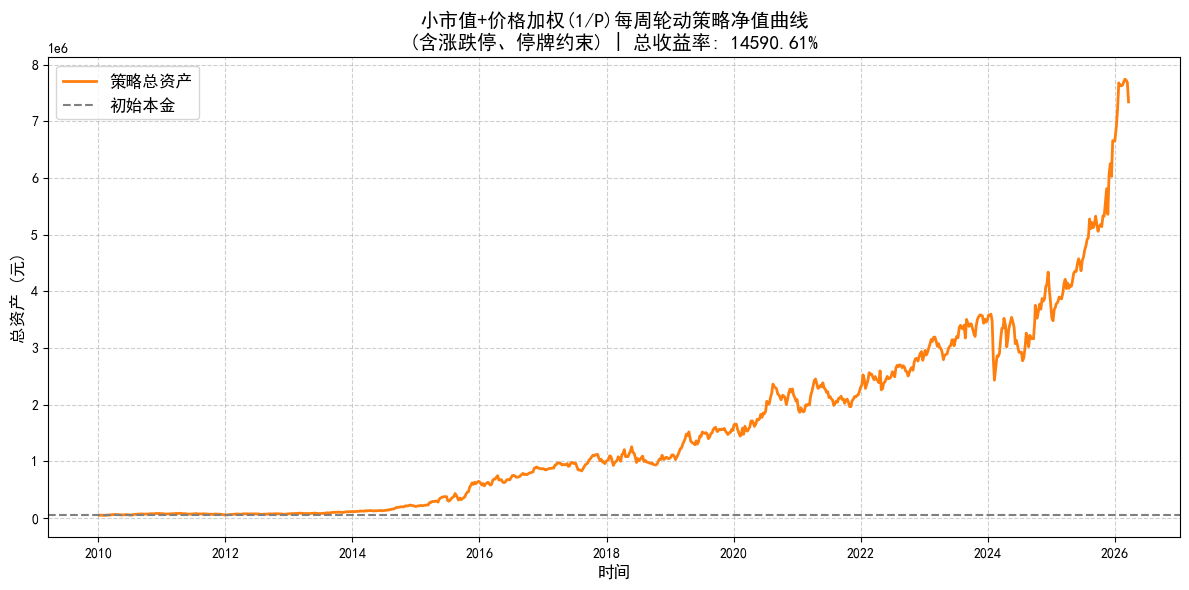

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# 设置绘图支持中文
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 第一步：配置参数与读取数据
# ==========================================
FILE_PATH = r"F:\self_quant\data\data\all_stocks_merged_fixed.parquet"
OUTPUT_EXCEL = r"F:\self_quant\quant\回测excel\小市值价格加权轮动策略明细_每周_清退市.xlsx"

INITIAL_CASH = 50000.0  # 初始本金 5万元
TARGET_STOCK_NUM = 8  # 目标持仓 10 只

print("正在读取全市场数据，请稍候...")
df = pd.read_parquet(FILE_PATH)
df['date'] = pd.to_datetime(df['date'])

# 过滤沪深主板股票
print("正在过滤沪深主板数据...")
main_board_mask = df['code'].str.contains(r'^sh\.60|^sz\.00', regex=True)
df = df[main_board_mask].copy()

df.sort_values(by=['date', 'code'], inplace=True)

# 提取每周的最后一个交易日作为调仓日
df['year_week'] = df['date'].dt.to_period('W')
trade_dates = df.groupby('year_week')['date'].max().sort_values().tolist()

# ==========================================
# 第二步：定义交易费率计算函数
# ==========================================
def calculate_fees(trade_type, price, volume):
    amount = price * volume
    commission = max(5.0, amount * 0.00025)
    transfer_fee = amount * 0.00001
    stamp_duty = amount * 0.0005 if trade_type == 'sell' else 0.0
    total_fee = commission + transfer_fee + stamp_duty
    return total_fee, amount

# ==========================================
# 第三步：账户类与回测主引擎
# ==========================================
class Account:
    def __init__(self, initial_cash):
        self.cash = initial_cash
        self.positions = {} # {code: {'volume': vol, 'price': last_price}}
        self.trade_logs = []
        self.history_assets = []

    def get_total_asset(self, current_date, current_prices_dict):
        stock_value = 0
        for code, pos in self.positions.items():
            price = current_prices_dict.get(code, pos['price'])
            self.positions[code]['price'] = price
            stock_value += pos['volume'] * price
        return self.cash + stock_value

account = Account(INITIAL_CASH)

print("开始按周执行小市值+价格加权调仓模拟...")

for date in trade_dates:
    daily_data = df[df['date'] == date].set_index('code')
    current_prices = daily_data['close'].to_dict()
    status_dict = daily_data['tradestatus'].to_dict()
    st_dict = daily_data['isST'].to_dict()
    pct_chg_dict = daily_data['pctChg'].to_dict()

    current_asset = account.get_total_asset(date, current_prices)
    account.history_assets.append({'date': date, 'total_asset': current_asset})

    # 选股逻辑
    valid_pool = daily_data[(daily_data['tradestatus'] == 1) &
                            (daily_data['isST'] == 0) &
                            (daily_data['peTTM'] > 0) &
                            (daily_data['close'] >= 1.5) &
                            (daily_data['pbMRQ'] > 0)].copy()

    target_codes = []
    if len(valid_pool) >= 50:
        smallest_50 = valid_pool.sort_values(by='流通市值', ascending=True).head(50).copy()
        target_codes = smallest_50.sort_values(by='close', ascending=True).head(TARGET_STOCK_NUM).index.tolist()

    if not target_codes:
        continue

    # 计算权重：价格越低，仓位越重 (1/Price)
    target_prices = daily_data.loc[target_codes, 'close']
    inv_prices = 1.0 / target_prices
    weights = inv_prices / inv_prices.sum()
    target_values = (weights * current_asset).to_dict()

    # ---------------- 卖出与调整逻辑 (先卖后买) ----------------
    current_holdings = list(account.positions.keys())
    
    # 1. 处理退市股
    for code in current_holdings:
        if code not in daily_data.index:
            lost_vol = account.positions[code]['volume']
            last_price = account.positions[code]['price']
            loss_amount = lost_vol * last_price
            del account.positions[code]
            account.trade_logs.append({
                '日期': date, '股票代码': code, '买卖方向': '强制清理(退市)',
                '成交价': 0, '成交股数': lost_vol, '成交金额': 0, '交易费': 0,
                '可用现金': round(account.cash, 2), '总资产': round(account.get_total_asset(date, current_prices), 2),
                '备注': f'退市，计提损失 {round(loss_amount, 2)}元'
            })

    # 2. 卖出非目标股 或 减仓目标股
    current_holdings = list(account.positions.keys())
    for code in current_holdings:
        is_trading = status_dict.get(code, 0) == 1
        pct_chg = pct_chg_dict.get(code, 0)
        
        if not is_trading or pct_chg <= -9.3:
            continue # 无法交易

        curr_vol = account.positions[code]['volume']
        curr_price = current_prices[code]
        
        if code not in target_codes:
            # 全卖
            fee, amount = calculate_fees('sell', curr_price, curr_vol)
            account.cash += (amount - fee)
            del account.positions[code]
            account.trade_logs.append({
                '日期': date, '股票代码': code, '买卖方向': '卖出(调出)',
                '成交价': curr_price, '成交股数': curr_vol, '成交金额': round(amount, 2), '交易费': round(fee, 2),
                '可用现金': round(account.cash, 2), '总资产': round(account.get_total_asset(date, current_prices), 2),
                '备注': '调出股票全卖'
            })
        else:
            # 目标股，检查是否需要减仓
            target_val = target_values[code]
            target_vol = int((target_val / curr_price) // 100) * 100
            if curr_vol > target_vol:
                sell_vol = curr_vol - target_vol
                if sell_vol >= 100:
                    fee, amount = calculate_fees('sell', curr_price, sell_vol)
                    account.cash += (amount - fee)
                    account.positions[code]['volume'] = target_vol
                    account.trade_logs.append({
                        '日期': date, '股票代码': code, '买卖方向': '卖出(减仓)',
                        '成交价': curr_price, '成交股数': sell_vol, '成交金额': round(amount, 2), '交易费': round(fee, 2),
                        '可用现金': round(account.cash, 2), '总资产': round(account.get_total_asset(date, current_prices), 2),
                        '备注': f'目标权重调整，减仓 {sell_vol}股'
                    })

    # 3. 买入新股 或 加仓目标股
    for code in target_codes:
        is_trading = status_dict.get(code, 0) == 1
        pct_chg = pct_chg_dict.get(code, 0)
        if not is_trading or pct_chg >= 9.3:
            continue
            
        curr_price = current_prices[code]
        curr_vol = account.positions.get(code, {}).get('volume', 0)
        target_val = target_values[code]
        target_vol = int((target_val / curr_price) // 100) * 100
        
        if target_vol > curr_vol:
            buy_vol = target_vol - curr_vol
            fee, amount = calculate_fees('buy', curr_price, buy_vol)
            if account.cash >= (amount + fee):
                account.cash -= (amount + fee)
                if code in account.positions:
                    account.positions[code]['volume'] += buy_vol
                    account.positions[code]['price'] = curr_price
                else:
                    account.positions[code] = {'volume': buy_vol, 'price': curr_price}
                
                account.trade_logs.append({
                    '日期': date, '股票代码': code, '买卖方向': '买入(加仓)' if curr_vol > 0 else '买入(建仓)',
                    '成交价': curr_price, '成交股数': buy_vol, '成交金额': round(amount, 2), '交易费': round(fee, 2),
                    '可用现金': round(account.cash, 2), '总资产': round(account.get_total_asset(date, current_prices), 2),
                    '备注': f'权重调整，加仓 {buy_vol}股' if curr_vol > 0 else '建仓'
                })

# ==========================================
# 第四步：输出结果与可视化
# ==========================================
df_trades = pd.DataFrame(account.trade_logs)
df_trades.to_excel(OUTPUT_EXCEL, index=False)
print(f"\n✅ 交易明细已成功导出至: {OUTPUT_EXCEL}")

df_assets = pd.DataFrame(account.history_assets)
df_assets.set_index('date', inplace=True)
final_asset = df_assets['total_asset'].iloc[-1]
total_return = (final_asset - INITIAL_CASH) / INITIAL_CASH * 100

print(f"💰 初始本金: {INITIAL_CASH:,.2f} 元")
print(f"💰 最终总资产: {final_asset:,.2f} 元")
print(f"📈 策略总收益率: {total_return:.2f}%")

# 绘制收益曲线
plt.figure(figsize=(12, 6))
plt.plot(df_assets.index, df_assets['total_asset'], color='#ff7f0e', linewidth=2, label='策略总资产')
plt.title(f'小市值+价格加权(1/P)每周轮动策略净值曲线\n(含涨跌停、停牌约束) | 总收益率: {total_return:.2f}%', fontsize=14)
plt.xlabel('时间', fontsize=12)
plt.ylabel('总资产 (元)', fontsize=12)
plt.axhline(y=INITIAL_CASH, color='gray', linestyle='--', label='初始本金')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()